# E-Commerce Data Analysis & Insights
This notebook explores the E-Commerce dataset using Visualization, Clustering, Association Rules, and Classification.

### Goals:
1. **EDA & Visualization**: Understand sales trends, top products, and geography.
2. **Clustering (Customer Segmentation)**: RFM Analysis + K-Means.
3. **Association Rules**: Market Basket Analysis using Apriori.
4. **Classification**: Predict High-Value Customers.
\n

In [ ]:
pip install mlxtend

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Loading & Preprocessing\n

In [13]:
# Load Data
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

print(f"Data shape: {df.shape}")
display(df.head())


Data shape: (112803, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [14]:
# Preprocessing
# 1. Drop missing CustomerID
df.dropna(subset=['CustomerID'], inplace=True)
df['CustomerID'] = df['CustomerID'].astype(int)


In [15]:
# 2. Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


In [16]:
# 3. Remove canceled orders and negative quantities
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [17]:
# 4. Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print(f"Data shape after cleaning: {df.shape}")

Data shape after cleaning: (72889, 9)


## 2. Exploratory Data Analysis & Visualization\n

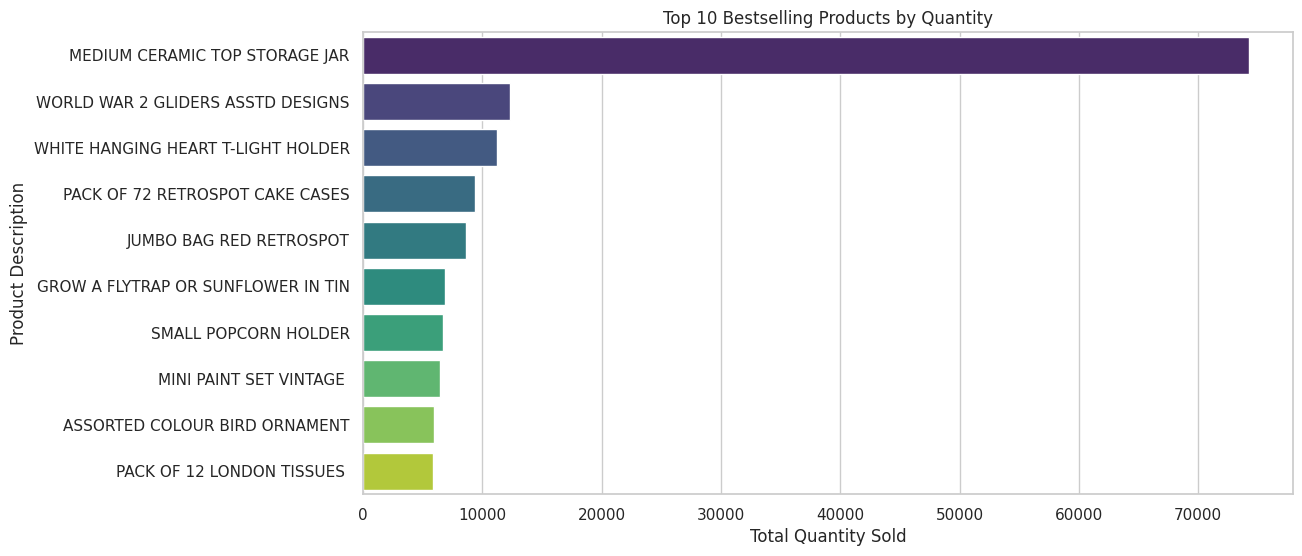

In [18]:
# Top 10 Bestselling Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Bestselling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')
plt.show()

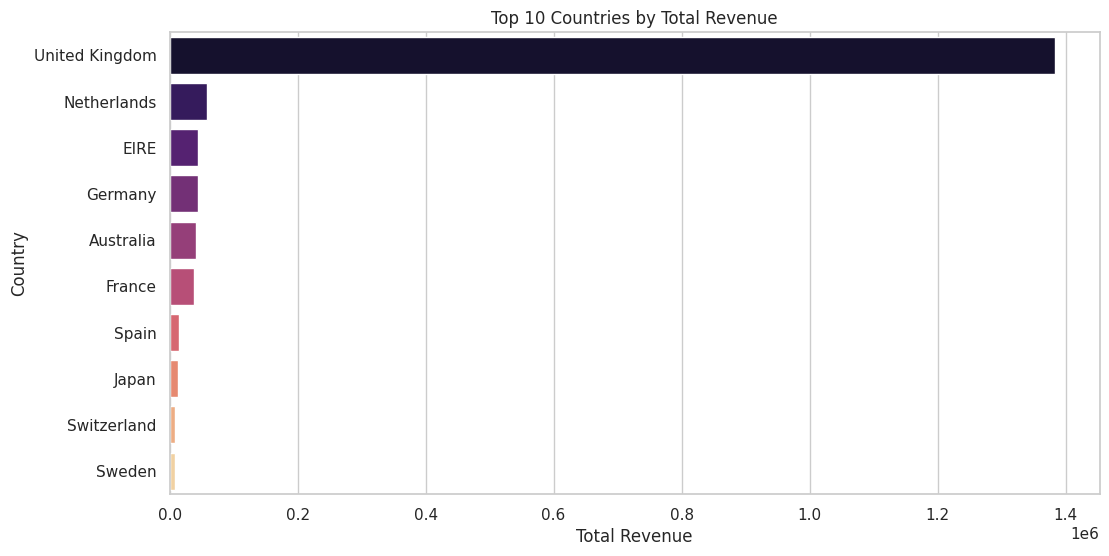

In [19]:
# Top 10 Countries by Revenue
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()


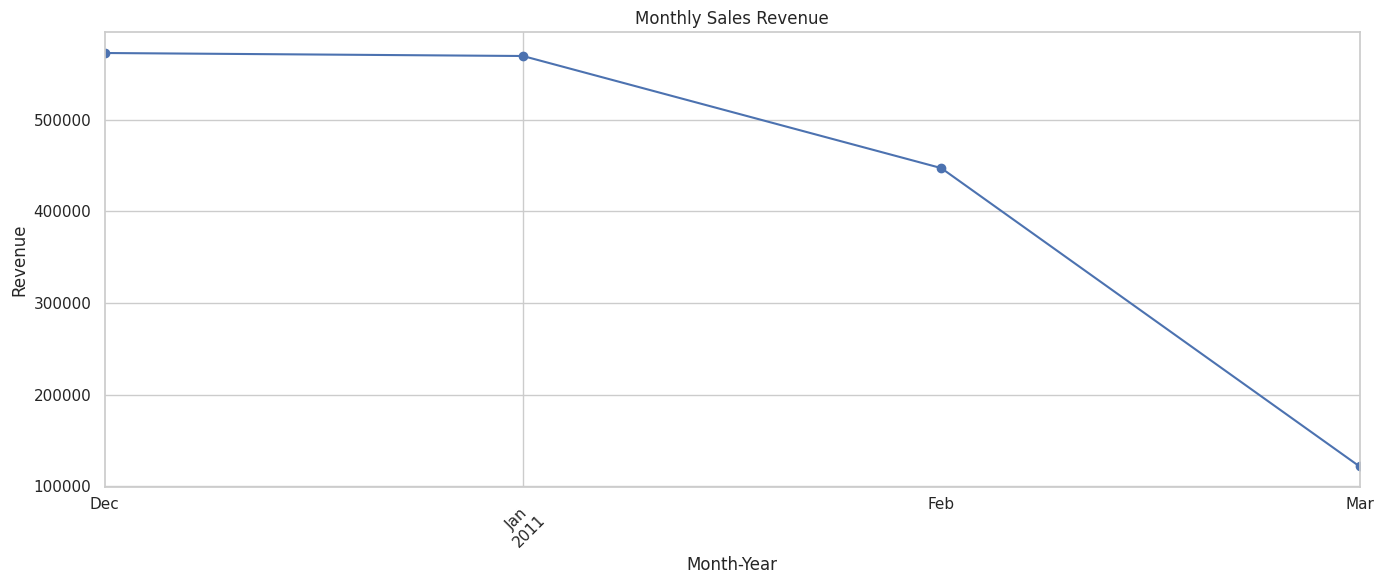

In [20]:
# Monthly Revenue trend
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('MonthYear')['Revenue'].sum()
plt.figure(figsize=(14, 6))
monthly_rev.plot(kind='line', marker='o')
plt.title('Monthly Sales Revenue')
plt.xlabel('Month-Year')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Clustering: Customer Segmentation (RFM + K-Means)\n

In [21]:
# Create RFM Features
snapshot_date = df['InvoiceDate'].max() + timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'Revenue': 'MonetaryValue'}, inplace=True)
rfm

,Recency,Frequency,MonetaryValue
CustomerID,,,
12346,49,1,77183.60
12347,41,2,1187.18
12348,42,2,1120.24
12350,34,1,334.40
12352,7,3,1281.15
...,...,...,...
18259,90,1,376.30
18260,58,2,787.77
18269,90,1,168.60


In [22]:
# Remove outliers for better clustering
q = rfm['MonetaryValue'].quantile(0.99)
rfm = rfm[rfm['MonetaryValue'] < q]


In [23]:
# Scale features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [24]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [25]:
# Assign meaningful names
cluster_means = rfm.groupby('Cluster').mean()
print("Cluster Centers (Mean Values):")
display(cluster_means)

Cluster Centers (Mean Values):


,Recency,Frequency,MonetaryValue
Cluster,,,
0,23.351476,1.810886,592.230581
1,79.819757,1.214905,381.706672
2,18.270270,7.108108,3570.378739


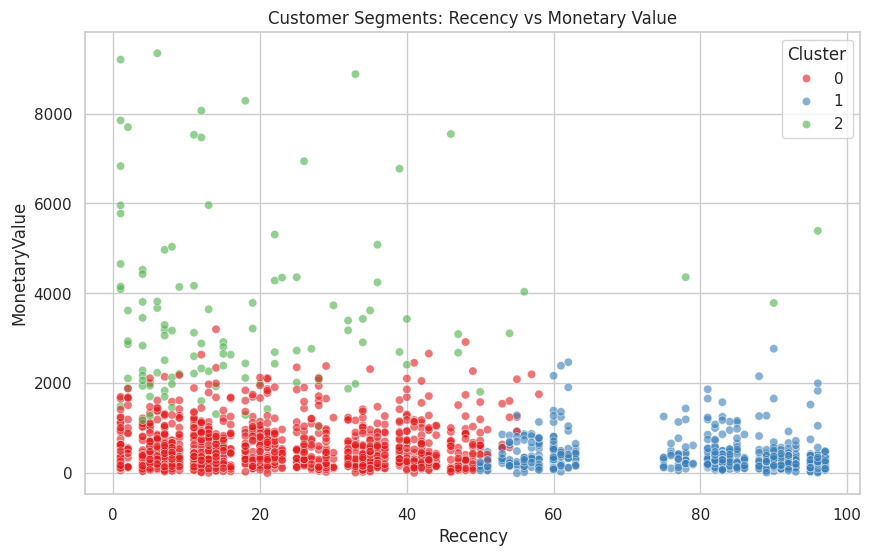

In [26]:
# Plotting Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='MonetaryValue', hue='Cluster', palette='Set1', alpha=0.6)
plt.title('Customer Segments: Recency vs Monetary Value')
plt.show()

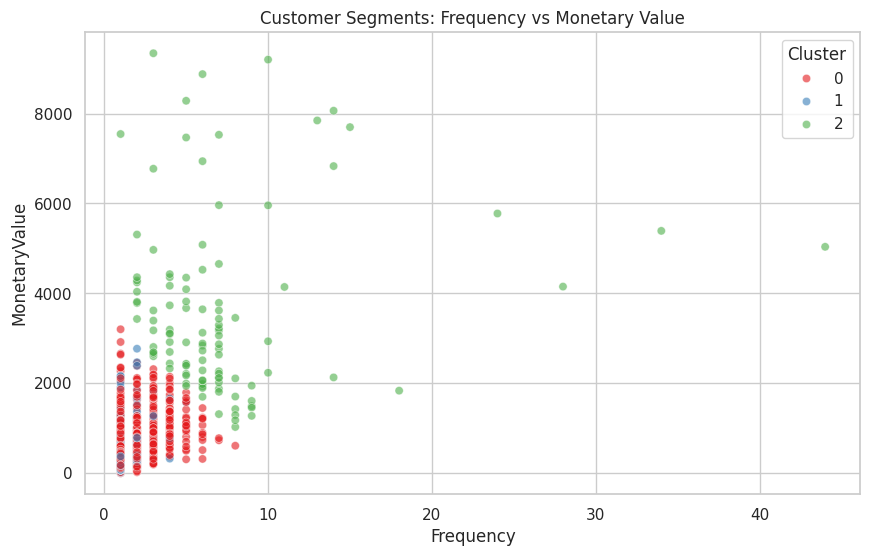

In [27]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='MonetaryValue', hue='Cluster', palette='Set1', alpha=0.6)
plt.title('Customer Segments: Frequency vs Monetary Value')
plt.show()

## 4. Association Rules: Market Basket Analysis\n

In [28]:
# We will analyze transactions from the UK (the largest market) to avoid memory issues
basket = (df[df['Country'] =="United Kingdom"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

In [29]:
# Binarize the data (1 if item present, 0 otherwise)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = basket.applymap(encode_units)

In [30]:
# Find Frequent Itemsets using Apriori
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)

# Generate Rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules = rules.sort_values('lift', ascending=False)

print("Top 10 Association Rules:")
display(rules.head(10))

Top 10 Association Rules:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
49,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.025734,0.027248,0.020587,0.800000,29.360000,1.0,0.019886,4.863760,0.991454,0.635514,0.794398,0.777778
48,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE BEDROOM ),0.027248,0.025734,0.020587,0.755556,29.360000,1.0,0.019886,3.985633,0.992997,0.635514,0.749099,0.777778
19,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.040872,0.043899,0.032092,0.785185,17.885977,1.0,0.030298,4.450813,0.984321,0.609195,0.775322,0.758110
18,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.043899,0.040872,0.032092,0.731034,17.885977,1.0,0.030298,3.565989,0.987438,0.609195,0.719573,0.758110
66,(WOOD S/3 CABINET ANT WHITE FINISH),(WOOD 2 DRAWER CABINET WHITE FINISH),0.038753,0.041175,0.023918,0.617188,14.989488,1.0,0.022322,2.504687,0.970912,0.427027,0.600748,0.599035
67,(WOOD 2 DRAWER CABINET WHITE FINISH),(WOOD S/3 CABINET ANT WHITE FINISH),0.041175,0.038753,0.023918,0.580882,14.989488,1.0,0.022322,2.293502,0.973365,0.427027,0.563986,0.599035
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.050863,0.049955,0.034514,0.678571,13.583766,1.0,0.031973,2.955697,0.976026,0.520548,0.661670,0.684740
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.049955,0.050863,0.034514,0.690909,13.583766,1.0,0.031973,3.070738,0.975093,0.520548,0.674345,0.684740
69,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.056312,0.049955,0.034817,0.618280,12.376833,1.0,0.032004,2.488851,0.974055,0.487288,0.598208,0.657625
68,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.049955,0.056312,0.034817,0.696970,12.376833,1.0,0.032004,3.114169,0.967537,0.487288,0.678887,0.657625


## 5. Classification: Predicting High-Value Customers\n

In [31]:
# Target Definition: High-Value Customer (Top 25% by Monetary Value)
threshold = rfm['MonetaryValue'].quantile(0.75)
rfm['HighValue'] = (rfm['MonetaryValue'] >= threshold).astype(int)

In [32]:
# Features and Target
# To make it interesting, let's pretend we only have Recency and Frequency to predict Monetary Value class
X = rfm[['Recency', 'Frequency']]
y = rfm['HighValue']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
# Train Classifier
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [35]:
# Predictions
y_pred = clf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       263
           1       0.74      0.53      0.62        92

    accuracy                           0.83       355
   macro avg       0.80      0.73      0.76       355
weighted avg       0.82      0.83      0.82       355



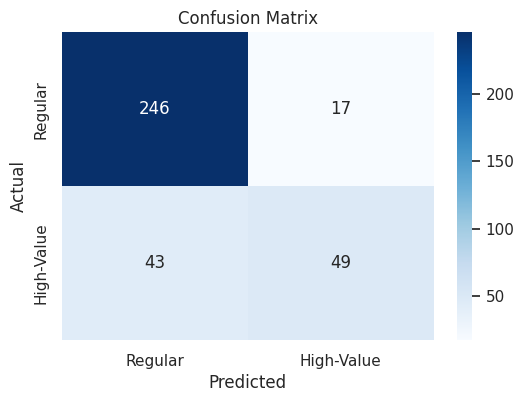

In [36]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Regular', 'High-Value'], yticklabels=['Regular', 'High-Value'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

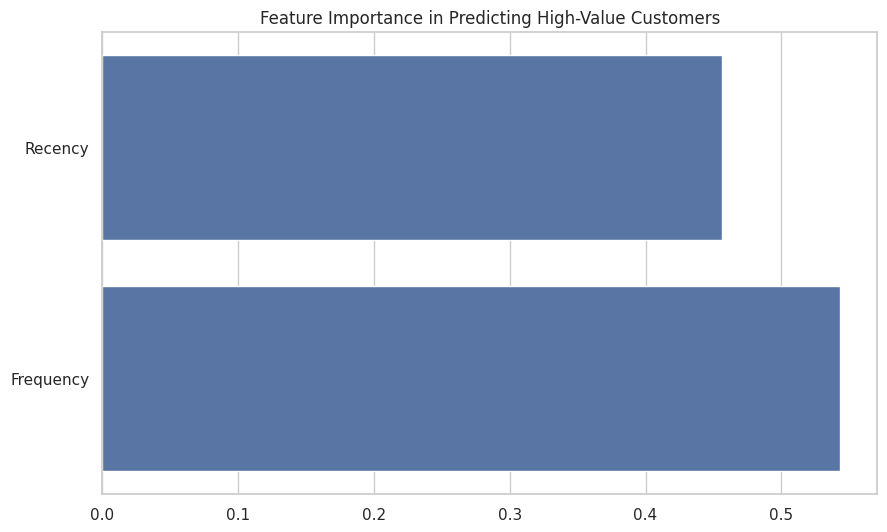

In [37]:
# Feature Importance
importances = clf.feature_importances_
sns.barplot(x=importances, y=['Recency', 'Frequency'])
plt.title('Feature Importance in Predicting High-Value Customers')
plt.show()

## 6. Model Improvement: Hyperparameter Tuning

In [38]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20],      # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]   # Minimum number of samples required to split an internal node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,  # 3-fold cross-validation
                           scoring='accuracy', # Optimize for accuracy
                           n_jobs=-1, # Use all available cores
                           verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation accuracy: 0.8215


### Evaluating the Tuned Model

Classification Report for Tuned Model:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       263
           1       0.73      0.57      0.64        92

    accuracy                           0.83       355
   macro avg       0.80      0.75      0.77       355
weighted avg       0.83      0.83      0.83       355



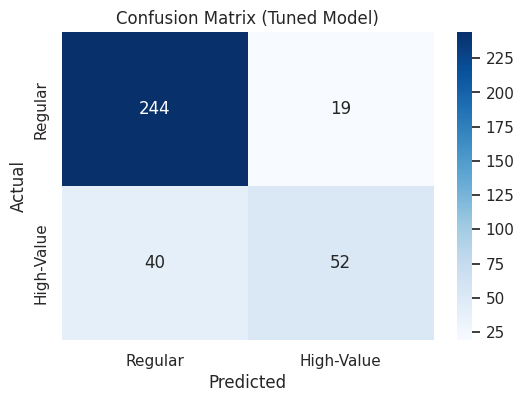

In [39]:
# Get the best model from GridSearchCV
best_clf = grid_search.best_estimator_

# Make predictions with the best model
y_pred_tuned = best_clf.predict(X_test)

print("Classification Report for Tuned Model:")
print(classification_report(y_test, y_pred_tuned))

# Confusion Matrix for Tuned Model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Regular', 'High-Value'], yticklabels=['Regular', 'High-Value'])
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 7. Further Model Improvement: Adding More Features

In [40]:
# Add RFM Cluster as a new feature
# Ensure 'rfm' DataFrame has the 'Cluster' column and is aligned with 'X'
X = rfm[['Recency', 'Frequency', 'Cluster']]

print("Features after adding Cluster:")
display(X.head())

Features after adding Cluster:


,Recency,Frequency,Cluster
CustomerID,,,
12347,41,2,0
12348,42,2,0
12350,34,1,0
12352,7,3,0
12356,49,1,0


In [41]:
# Re-split the data with the new features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
# Re-train the best model from GridSearchCV with the new features
best_clf_improved = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=1)

best_clf_improved.fit(X_train_new, y_train_new)

print(f"Best parameters found with new features: {best_clf_improved.best_params_}")
print(f"Best cross-validation accuracy with new features: {best_clf_improved.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters found with new features: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation accuracy with new features: 0.8320


### Evaluating the Improved Tuned Model

Classification Report for Tuned Model with New Features:
              precision    recall  f1-score   support

           0       0.87      0.94      0.91       263
           1       0.79      0.60      0.68        92

    accuracy                           0.85       355
   macro avg       0.83      0.77      0.79       355
weighted avg       0.85      0.85      0.85       355



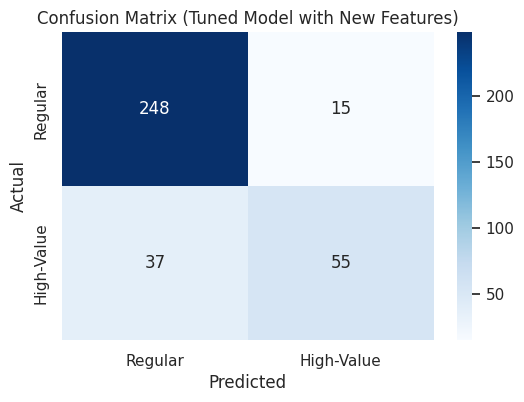

In [43]:
# Get the best model from the improved GridSearchCV
best_clf_final = best_clf_improved.best_estimator_

# Make predictions with the best model
y_pred_final = best_clf_final.predict(X_test_new)

print("Classification Report for Tuned Model with New Features:")
print(classification_report(y_test_new, y_pred_final))

# Confusion Matrix for Tuned Model with New Features
cm_final = confusion_matrix(y_test_new, y_pred_final)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', xticklabels=['Regular', 'High-Value'], yticklabels=['Regular', 'High-Value'])
plt.title('Confusion Matrix (Tuned Model with New Features)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

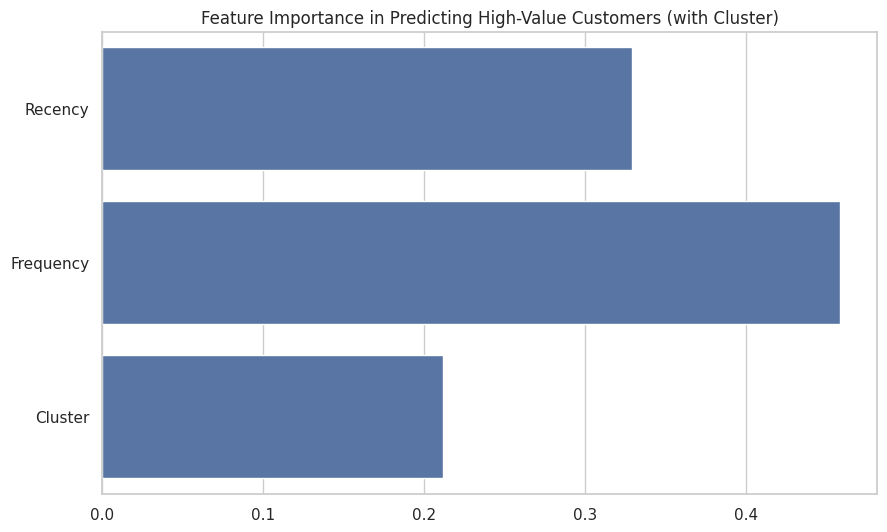

In [44]:
# Feature Importance with new features
importances_final = best_clf_final.feature_importances_
sns.barplot(x=importances_final, y=['Recency', 'Frequency', 'Cluster'])
plt.title('Feature Importance in Predicting High-Value Customers (with Cluster)')
plt.show()